# Sequential CAV debiasing

Pipeline for a single concept:
1. Runs CLIP layer by layer.
2. At each layer: computes CAV (diff_means / lr / pclarc), measures accuracy, applies debiasing.
3. Each subsequent layer receives activations already debiased at all previous layers.
4. Saves **pre-debiasing** and **post-debiasing** activations separately at every layer.
5. After all 24 CAVs are trained, runs one full forward pass with all hooks active to save the final model output.

**Change only `CONCEPT`** — everything else follows automatically.

Output structure:
```
data/activations/debiased/sequential/{CONCEPT}/{method}/
  train/
    layer_00_pre.parquet   # activations at layer 0 before debiasing (after 0..L-1 debiasings)
    layer_00_post.parquet  # activations at layer 0 after debiasing
    ...
    model_output.parquet   # 768-dim CLIP image embedding with all 24 CAVs applied
  test/  (same)
  cavs.csv                 # CAV vectors + metrics per layer
  info.json
```

Parquet schema: `filename (str), 0..1023 (float16)` for layers; `filename (str), 0..767 (float16)` for model_output.

In [1]:
import json
import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from dotenv import load_dotenv
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from transformers import AutoModel, AutoImageProcessor
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
load_dotenv()

ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / 'pyproject.toml').exists():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from software.torch_lr import TorchLR
from software.viz import plot_cav_accuracy_per_layer

In [2]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
CONCEPT        = 'eyeglasses'
NUM_LAYERS     = 24
GPU_BATCH_SIZE = 64
NUM_WORKERS    = 4
MODEL_ID       = 'openai/clip-vit-large-patch14'
PARQUET_COMPRESSION = 'snappy'
METHODS        = ['diff_means', 'lr', 'pclarc']

# Solver for LR-based CAV (method='lr'):
#   'torch_lr' — TorchLR (LBFGS on GPU, stable, recommended)
#   'sgd'      — SGDClassifier from sklearn (stochastic gradient descent)
SOLVER   = 'torch_lr'
SOLVER_C = 0.1

METADATA_PATH = ROOT / 'data' / 'metadata.csv'
IMAGES_DIR    = ROOT / 'data' / 'images'
DATA_OUT      = ROOT / 'data' / 'activations' / 'debiased' / 'sequential' / CONCEPT
PLOT_DIR      = ROOT / 'notebooks' / 'results' / 'multiple_debias' / CONCEPT / 'sequential_debiasing'

assert METADATA_PATH.exists(), f'Missing: {METADATA_PATH}'
assert IMAGES_DIR.exists(),    f'Missing: {IMAGES_DIR}'

for m in METHODS:
    for split in ('train', 'test'):
        (DATA_OUT / m / split).mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df_meta  = pd.read_csv(METADATA_PATH)
assert CONCEPT in df_meta.columns, f'Column "{CONCEPT}" not in metadata.csv'
df_train = df_meta[df_meta['split'] == 'train'].reset_index(drop=True)
df_test  = df_meta[df_meta['split'] == 'test'].reset_index(drop=True)

print(f'Concept  : {CONCEPT}')
print(f'Solver   : {SOLVER} (C={SOLVER_C})')
print(f'Train    : {len(df_train)} | Test: {len(df_test)}')
print(f'Data out : {DATA_OUT}')

Concept  : eyeglasses
Solver   : torch_lr (C=0.1)
Train    : 4642 | Test: 715
Data out : /workspace/WB2/data/activations/debiased/sequential/eyeglasses


In [4]:
HF_TOKEN = os.getenv('HF_TOKEN')
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype    = torch.bfloat16 if device == 'cuda' else torch.float32

processor = AutoImageProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model = AutoModel.from_pretrained(
    MODEL_ID, torch_dtype=dtype, low_cpu_mem_usage=True, token=HF_TOKEN,
).to(device).eval()
print(f'Model: {MODEL_ID} | {device} | {dtype}')


class CelebADataset(Dataset):
    def __init__(self, df, images_dir, processor):
        self.df = df.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.processor  = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.images_dir / row['filename']).convert('RGB')
        px  = self.processor(images=img, return_tensors='pt').pixel_values.squeeze(0)
        return px, row['filename'], int(row[CONCEPT])


def make_loader(df):
    return DataLoader(
        CelebADataset(df, IMAGES_DIR, processor),
        batch_size=GPU_BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(device == 'cuda'),
        persistent_workers=(NUM_WORKERS > 0),
    )


loader_train = make_loader(df_train)
loader_test  = make_loader(df_test)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Model: openai/clip-vit-large-patch14 | cuda | torch.bfloat16


In [5]:
class _StopForward(Exception):
    pass


def make_cav_clf():
    """LR classifier for CAV training (no CV — C fixed by SOLVER_C)."""
    if SOLVER == 'torch_lr':
        return TorchLR(C=SOLVER_C, max_iter=500, random_state=42)
    return SGDClassifier(
        loss='log_loss', penalty='l2',
        alpha=1.0 / (2.0 * SOLVER_C),
        max_iter=1000, tol=1e-4, random_state=42,
    )


def _make_debias_hook(cav_np, method, target_val=None):
    cav = torch.from_numpy(cav_np).float()

    def hook(module, input, output):
        is_tuple = isinstance(output, tuple)
        hidden   = output[0] if is_tuple else output
        cls      = hidden[:, 0, :].float()
        cav_d    = cav.to(cls.device)
        proj     = cls @ cav_d
        if method in ('diff_means', 'lr'):
            cls_new = cls - proj.unsqueeze(1) * cav_d
        else:
            t       = torch.tensor(target_val, dtype=torch.float32, device=cls.device)
            cls_new = cls + (t - proj).unsqueeze(1) * cav_d
        h_new = hidden.clone()
        h_new[:, 0, :] = cls_new.to(hidden.dtype)
        return (h_new,) + output[1:] if is_tuple else h_new

    return hook


def run_to_layer(loader, target_layer, past_cavs, method):
    encoder_layers = model.vision_model.encoder.layers
    handles = []
    for k, (cav_np, t_val) in enumerate(past_cavs):
        handles.append(encoder_layers[k].register_forward_hook(
            _make_debias_hook(cav_np, method, t_val)
        ))
    _buf = []

    def _capture(module, input, output):
        hidden = output[0] if isinstance(output, tuple) else output
        _buf.append(hidden[:, 0, :].detach().float().cpu().numpy())
        raise _StopForward()

    handles.append(encoder_layers[target_layer].register_forward_hook(_capture))
    X_all, y_all, fn_all = [], [], []
    try:
        with torch.no_grad():
            for pixels, fnames, labels in loader:
                _buf.clear()
                try:
                    model.get_image_features(pixel_values=pixels.to(device, dtype=dtype))
                except _StopForward:
                    pass
                if _buf:
                    X_all.append(_buf[0])
                y_all.extend(labels.tolist())
                fn_all.extend(fnames)
    finally:
        for h in handles:
            h.remove()
    return np.concatenate(X_all, axis=0), list(fn_all), np.array(y_all, dtype=int)


def compute_diff_means(X_tr, y_tr):
    X = X_tr.astype(np.float64)
    diff = X[y_tr == 1].mean(axis=0) - X[y_tr == 0].mean(axis=0)
    return (diff / np.linalg.norm(diff)).astype(np.float32)


def compute_lr_cav(X_tr, y_tr):
    clf = make_cav_clf()
    clf.fit(X_tr, y_tr)
    w = clf.coef_[0].astype(np.float64)
    return (w / np.linalg.norm(w)).astype(np.float32), clf


def fit_dm_threshold(X_tr, y_tr, cav):
    proj = X_tr.astype(np.float64) @ cav.astype(np.float64)
    return float((proj[y_tr == 1].mean() + proj[y_tr == 0].mean()) / 2)


def apply_orthogonal(X, cav):
    X64 = X.astype(np.float64)
    c64 = cav.astype(np.float64)
    return (X64 - np.outer(X64 @ c64, c64)).astype(np.float32)


def apply_pclarc(X, cav, target_val):
    X64 = X.astype(np.float64)
    c64 = cav.astype(np.float64)
    return (X64 + np.outer(target_val - X64 @ c64, c64)).astype(np.float32)


def save_activations(X, filenames, method, layer_idx, split_name, suffix):
    df = pd.DataFrame(X.astype(np.float16))
    df.columns = df.columns.astype(str)
    df.insert(0, 'filename', filenames)
    path = DATA_OUT / method / split_name / f'layer_{layer_idx:02d}_{suffix}.parquet'
    df.to_parquet(path, compression=PARQUET_COMPRESSION, index=False)

In [6]:
def run_full_with_all_cavs(loader, cavs_list, method):
    """Full forward pass with all debiasing hooks active at layers 0..23.
    Returns (outputs_768, filenames) — the 768-dim CLIP image embeddings after all debiasings.
    """
    encoder_layers = model.vision_model.encoder.layers
    handles        = []
    outputs_buf    = []
    fn_all         = []

    for layer_idx, (cav_np, target_val) in enumerate(cavs_list):
        handles.append(encoder_layers[layer_idx].register_forward_hook(
            _make_debias_hook(cav_np, method, target_val)
        ))

    def capture_output(module, input, output):
        outputs_buf.append(output.detach().float().cpu().numpy())

    handles.append(model.visual_projection.register_forward_hook(capture_output))

    try:
        with torch.no_grad():
            for pixels, fnames, labels in loader:
                model.get_image_features(pixel_values=pixels.to(device, dtype=dtype))
                fn_all.extend(fnames)
    finally:
        for h in handles:
            h.remove()

    return np.concatenate(outputs_buf, axis=0), list(fn_all)


def save_model_output(outputs, filenames, method, split_name):
    df = pd.DataFrame(outputs.astype(np.float16))
    df.columns = df.columns.astype(str)
    df.insert(0, 'filename', filenames)
    path = DATA_OUT / method / split_name / 'model_output.parquet'
    df.to_parquet(path, compression=PARQUET_COMPRESSION, index=False)

In [7]:
methods_to_run = [m for m in METHODS if not (DATA_OUT / m / 'cavs.csv').exists()]

if not methods_to_run:
    print('All methods already computed — skipping pipeline.')
else:
    print(f'Methods to compute: {methods_to_run}')
    state       = {m: [] for m in methods_to_run}
    cav_records = {m: [] for m in methods_to_run}

    for layer_idx in tqdm(range(NUM_LAYERS), desc='Layers'):
        for method in tqdm(methods_to_run, desc=f'L{layer_idx:02d}', leave=False):
            past = state[method]

            X_tr_pre, fn_tr, y_tr = run_to_layer(loader_train, layer_idx, past, method)
            X_te_pre, fn_te, y_te = run_to_layer(loader_test,  layer_idx, past, method)

            # ── Train CAV ──
            best_C = threshold = target_val = None

            if method == 'lr':
                cav, clf = compute_lr_cav(X_tr_pre, y_tr)
                acc_tr = clf.score(X_tr_pre, y_tr)
                acc_te = clf.score(X_te_pre, y_te)
                best_C = float(getattr(clf, 'C_', [SOLVER_C])[0]) if hasattr(clf, 'C_') else SOLVER_C
            else:
                cav       = compute_diff_means(X_tr_pre, y_tr)
                threshold = fit_dm_threshold(X_tr_pre, y_tr, cav)
                proj_tr   = X_tr_pre.astype(np.float64) @ cav.astype(np.float64)
                proj_te   = X_te_pre.astype(np.float64) @ cav.astype(np.float64)
                acc_tr    = accuracy_score(y_tr, (proj_tr > threshold).astype(int))
                acc_te    = accuracy_score(y_te, (proj_te > threshold).astype(int))

            if method == 'pclarc':
                target_val  = float((X_tr_pre.astype(np.float64)[y_tr == 0] @ cav.astype(np.float64)).mean())
                X_tr_post   = apply_pclarc(X_tr_pre, cav, target_val)
                X_te_post   = apply_pclarc(X_te_pre, cav, target_val)
            else:
                X_tr_post   = apply_orthogonal(X_tr_pre, cav)
                X_te_post   = apply_orthogonal(X_te_pre, cav)

            # ── Save activations ──
            save_activations(X_tr_pre,  fn_tr, method, layer_idx, 'train', 'pre')
            save_activations(X_tr_post, fn_tr, method, layer_idx, 'train', 'post')
            save_activations(X_te_pre,  fn_te, method, layer_idx, 'test',  'pre')
            save_activations(X_te_post, fn_te, method, layer_idx, 'test',  'post')

            state[method].append((cav, target_val))
            cav_records[method].append({
                'layer_id':   layer_idx,
                'train_acc':  acc_tr,
                'test_acc':   acc_te,
                'threshold':  threshold,
                'target_val': target_val,
                'lr_best_C':  best_C,
                **{f'cav_{i}': float(cav[i]) for i in range(len(cav))},
            })

    for method in methods_to_run:
        pd.DataFrame(cav_records[method]).to_csv(DATA_OUT / method / 'cavs.csv', index=False)

        # Full forward pass with all 24 CAVs active → save final CLIP image embedding
        print(f'  Saving model outputs for {method}...')
        outputs_tr, fn_tr_out = run_full_with_all_cavs(loader_train, state[method], method)
        outputs_te, fn_te_out = run_full_with_all_cavs(loader_test,  state[method], method)
        save_model_output(outputs_tr, fn_tr_out, method, 'train')
        save_model_output(outputs_te, fn_te_out, method, 'test')
        print(f'  Done: {method}')

    print('Pipeline done.')

Methods to compute: ['diff_means', 'lr', 'pclarc']


Layers:   0%|          | 0/24 [00:00<?, ?it/s]

L00:   0%|          | 0/3 [00:00<?, ?it/s]

L01:   0%|          | 0/3 [00:00<?, ?it/s]

L02:   0%|          | 0/3 [00:00<?, ?it/s]

...

L23:   0%|          | 0/3 [00:00<?, ?it/s]

  Saving model outputs for diff_means...


  Done: diff_means
  Saving model outputs for lr...


  Done: lr
  Saving model outputs for pclarc...


  Done: pclarc
Pipeline done.


In [8]:
for method in METHODS:
    info = {
        'concept':             CONCEPT,
        'method':              method,
        'debias_type':         'sequential',
        'debias_start_layer':  0,
        'debias_end_layer':    NUM_LAYERS - 1,
        'layers_saved':        list(range(NUM_LAYERS)),
        'files_per_layer':     ['layer_XX_pre.parquet', 'layer_XX_post.parquet'],
        'model_output_saved':  True,
        'parquet_schema':      'filename (str), 0..1023 (float16)',
        'model_output_schema': 'filename (str), 0..767 (float16)',
        'model_id':            MODEL_ID,
        'n_features':          1024,
        'n_output_features':   768,
        'created_at':          datetime.now(timezone.utc).isoformat(),
        'description': (
            f"Sequential debiasing of concept '{CONCEPT}' using {method}. "
            f"At each layer L, the CAV is trained on activations already modified by layers 0..L-1. "
            f"'pre' files contain activations before debiasing at that layer (but after all previous layers). "
            f"'post' files contain activations after applying the debiasing projection at that layer. "
            f"model_output.parquet contains the 768-dim CLIP image embedding (post_layernorm + visual_projection, "
            f"before L2 norm) obtained with all 24 sequential debiasings applied simultaneously. "
            f"Labels and split info: join on 'filename' with data/metadata.csv."
        ),
    }
    with open(DATA_OUT / method / 'info.json', 'w') as f:
        json.dump(info, f, indent=2)
    print(f'Saved info.json for method={method}')

Saved info.json for method=diff_means
Saved info.json for method=lr
Saved info.json for method=pclarc


## Visualization: CAV accuracy per layer

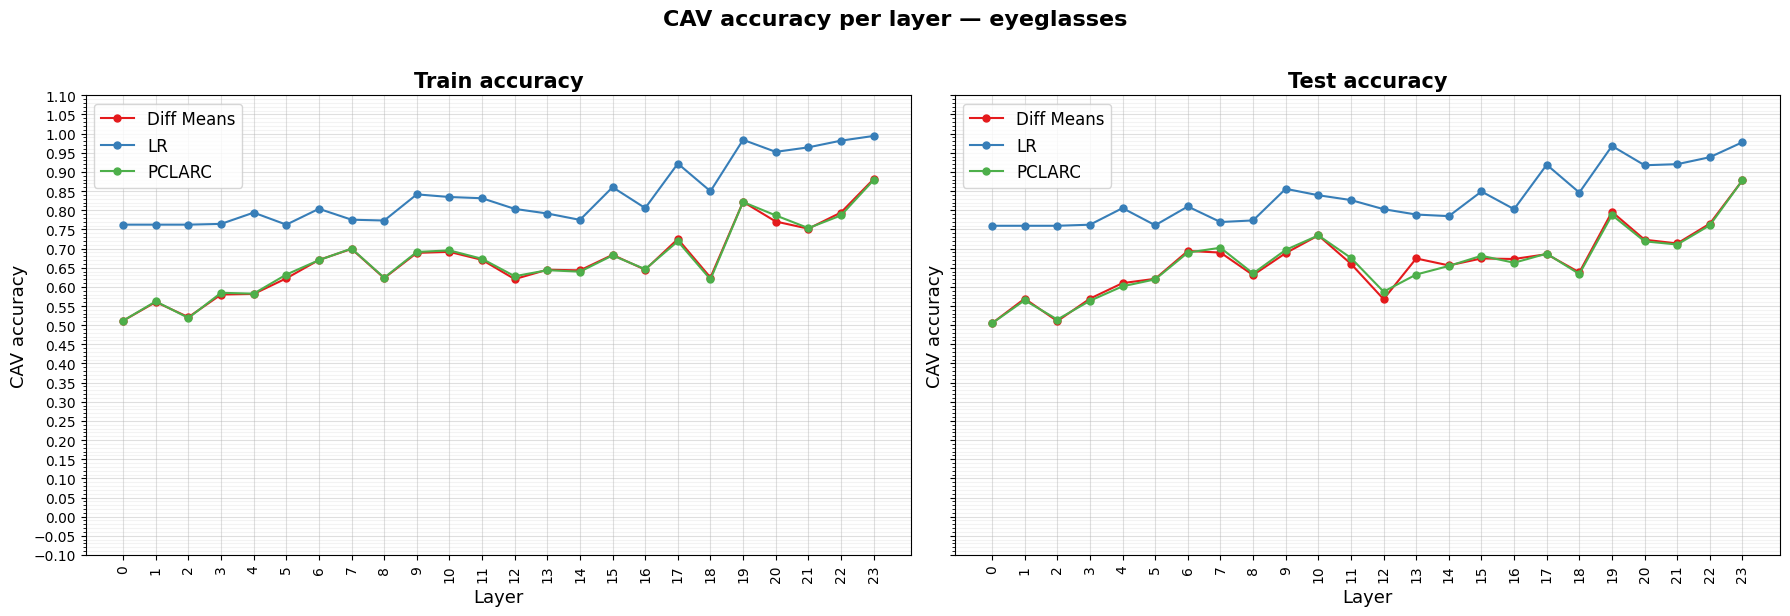

In [9]:
dfs = {}
for m in METHODS:
    p = DATA_OUT / m / 'cavs.csv'
    if p.exists():
        dfs[m] = pd.read_csv(p)[['layer_id', 'train_acc', 'test_acc']]

assert dfs, 'No results found — run pipeline above.'

plot_cav_accuracy_per_layer(
    dfs, CONCEPT,
    save_path=PLOT_DIR / f'cav_accuracy_per_layer_{CONCEPT}.png',
)